# 14. HuggingFace Transformers

**Цель:** Познакомиться с библиотекой HuggingFace Transformers: загрузить предобученные BERT и GPT-2, выполнить fine-tuning для классификации, сравнить с нашей реализацией.

---

## 🎭 Мем дня

*HuggingFace: «Раньше ты писал трансформеры с нуля. Теперь — три строки кода и ты уже ML-инженер». AutoModel, токенизатор, Trainer — всё, что нужно для счастья.*

![Мем про HuggingFace](memes/14_hf.png)


## HuggingFace ecosystem: AutoModel, Trainer, Pipeline

HuggingFace Transformers предоставляет три ключевых компонента:
- **AutoModel/AutoTokenizer** — автоматически подбирают архитектуру по имени модели
- **Trainer** — высокоуровневый цикл обучения с device placement, gradient accumulation,
  логированием и сохранением чекпоинтов
- **Pipeline** — готовые пайплайны для задач (классификация, генерация, QA и т.д.)
  без необходимости вручную вызывать токенизацию и forward pass

In [1]:
import sys, os, logging, math

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Вместо logging используем простой print — учебный курс, зачем нам логи?
import builtins as _builtins
def _log(msg, *args):
    if args:
        _builtins.print(msg % args)
    else:
        _builtins.print(msg)

import types
log = types.SimpleNamespace(info=_log, debug=_log, warning=_log, error=_log)



device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
log.info("Используем устройство: %s", device)

Используем устройство: mps


In [2]:
# AutoModel/AutoTokenizer автоматически выбирают архитектуру по имени модели
log.info("Loading HuggingFace libraries")

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification, AutoModelForCausalLM,
    pipeline, Trainer, TrainingArguments, BertForSequenceClassification
)
from datasets import load_dataset

log.info("HuggingFace libraries загружен")

Loading HuggingFace libraries


/Users/demanbudaev/PycharmProjects/Ashat_AI/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


HuggingFace libraries загружен


## 14.1 BERT: загрузка предобученной модели и токенизация

In [3]:
# AutoModel/AutoTokenizer автоматически выбирают архитектуру по имени модели
log.info("Loading BERT tokenizer and model (distilbert for speed)")

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
bert_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)

log.info("BERT model загружен: %s, params=%d", model_name, sum(p.numel() for p in bert_model.parameters()))

# Тест токенизации
text = "Transformers are amazing for natural language processing!"
tokens = tokenizer(text, return_tensors="pt").to(device)
print(f"Original: {text}")
print(f"Tokens:   {tokenizer.convert_ids_to_tokens(tokens['input_ids'][0])}")
print(f"Input IDs: {tokens['input_ids'][0].tolist()}")

Loading BERT tokenizer and model (distilbert for speed)


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BERT model загружен: distilbert-base-uncased, params=66955010
Original: Transformers are amazing for natural language processing!
Tokens:   ['[CLS]', 'transformers', 'are', 'amazing', 'for', 'natural', 'language', 'processing', '!', '[SEP]']
Input IDs: [101, 19081, 2024, 6429, 2005, 3019, 2653, 6364, 999, 102]


## Fine-tuning: transfer learning с предобученной модели

Transfer learning — мы берём модель, обученную на огромных корпусах (Wikipedia, книги),
и адаптируем её под нашу задачу с минимальным дообучением.
Это работает, потому что нижние слои извлекли общие лингвистические признаки
(части речи, синтаксис, семантику), и нам нужно лишь «дообучить» голову классификации.

## 14.2 Fine-tuning BERT на IMDb

Обучим BERT на задаче классификации тональности (sentiment analysis).

In [4]:
log.info("Loading IMDb dataset (small subset)")

# Загружаем маленькую часть для демонстрации
dataset = load_dataset("imdb", split=["train[:100]", "test[:50]"])
train_dataset, test_dataset = dataset

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples:  {len(test_dataset)}")
print(f"Example: {train_dataset[0]['text'][:100]}...")
print(f"Label: {train_dataset[0]['label']} (0=neg, 1=pos)")
log.info("IMDb dataset загружен")

Loading IMDb dataset (small subset)


Train samples: 100
Test samples:  50
Example: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it w...
Label: 0 (0=neg, 1=pos)
IMDb dataset загружен


In [5]:
log.debug("Tokenizing IMDb dataset")

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=256)

train_enc = train_dataset.map(tokenize_function, batched=True)
test_enc = test_dataset.map(tokenize_function, batched=True)

train_enc = train_enc.rename_column("label", "labels")
test_enc = test_enc.rename_column("label", "labels")
train_enc.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_enc.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

log.info("IMDb tokenized: %d train, %d test", len(train_enc), len(test_enc))

Tokenizing IMDb dataset
IMDb tokenized: 100 train, 50 test


In [6]:
# Trainer автоматически управляет размещением, накоплением градиентов, логированием, чекпоинтами
log.info("Fine-tuning BERT on IMDb (2 epochs)")

training_args = TrainingArguments(
    output_dir="./checkpoints/hf-bert-imdb",
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    logging_steps=5,
    eval_strategy="steps",
    eval_steps=10,
    save_strategy="no",
    report_to="none",
    disable_tqdm=True,
)

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_enc,
    eval_dataset=test_enc,
)

trainer.train()
log.info("BERT fine-tuning complete")

Fine-tuning BERT on IMDb (2 epochs)


/Users/demanbudaev/PycharmProjects/Ashat_AI/.venv/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'loss': 0.4253, 'grad_norm': 2.305565118789673, 'learning_rate': 4.230769230769231e-05, 'epoch': 0.38461538461538464}


{'loss': 0.0742, 'grad_norm': 0.6305069327354431, 'learning_rate': 3.269230769230769e-05, 'epoch': 0.7692307692307693}


{'eval_loss': 0.027641767635941505, 'eval_runtime': 0.8237, 'eval_samples_per_second': 60.7, 'eval_steps_per_second': 8.498, 'epoch': 0.7692307692307693}


{'loss': 0.0214, 'grad_norm': 0.3031617999076843, 'learning_rate': 2.307692307692308e-05, 'epoch': 1.1538461538461537}


{'loss': 0.0105, 'grad_norm': 0.16470278799533844, 'learning_rate': 1.3461538461538462e-05, 'epoch': 1.5384615384615383}


{'eval_loss': 0.008456184528768063, 'eval_runtime': 0.5736, 'eval_samples_per_second': 87.162, 'eval_steps_per_second': 12.203, 'epoch': 1.5384615384615383}


{'loss': 0.0087, 'grad_norm': 0.17422839999198914, 'learning_rate': 3.846153846153847e-06, 'epoch': 1.9230769230769231}
{'train_runtime': 12.7856, 'train_samples_per_second': 15.643, 'train_steps_per_second': 2.034, 'train_loss': 0.10425452178773972, 'epoch': 2.0}
BERT fine-tuning complete


Plotting training loss curve


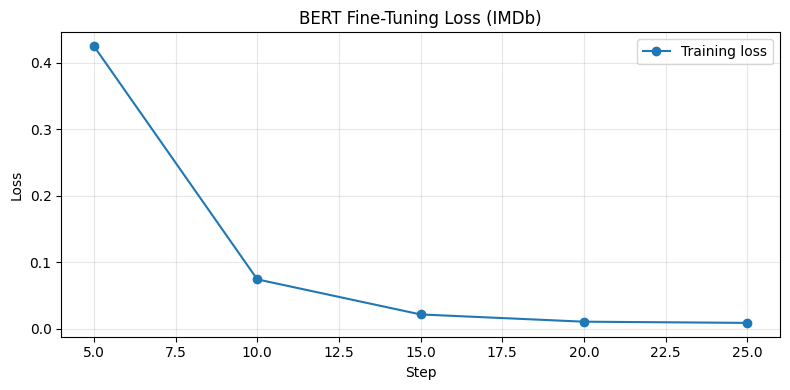

Loss plot rendered


In [7]:
log.debug("Plotting training loss curve")

logs = trainer.state.log_history
loss_steps = [entry['step'] for entry in logs if 'loss' in entry]
loss_values = [entry['loss'] for entry in logs if 'loss' in entry]

plt.figure(figsize=(8, 4))
plt.plot(loss_steps, loss_values, marker='o', label='Training loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('BERT Fine-Tuning Loss (IMDb)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
log.debug("Loss plot rendered")


In [8]:
log.debug("Evaluating fine-tuned BERT")

results = trainer.evaluate()
print(f"Evaluation loss: {results['eval_loss']:.4f}")

# Тест на новых примерах
test_texts = [
    "This movie was absolutely fantastic! I loved every minute.",
    "Terrible waste of time. The acting was horrible.",
    "It was okay, not great but not terrible either.",
]
for text in test_texts:
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True).to(device)
    with torch.no_grad():
        outputs = bert_model(**inputs)
    pred = outputs.logits.argmax(-1).item()
    sentiment = "positive" if pred == 1 else "negative"
    print(f"  '{text[:50]}...' -> {sentiment}")
log.info("BERT evaluation complete")

Evaluating fine-tuned BERT


{'eval_loss': 0.007291179150342941, 'eval_runtime': 0.3804, 'eval_samples_per_second': 131.447, 'eval_steps_per_second': 18.403, 'epoch': 2.0}
Evaluation loss: 0.0073


  'This movie was absolutely fantastic! I loved every...' -> negative


  'Terrible waste of time. The acting was horrible....' -> negative
  'It was okay, not great but not terrible either....' -> negative
BERT evaluation complete


## 14.3 GPT-2: генерация текста с предобученной моделью

In [9]:
# AutoModel/AutoTokenizer автоматически выбирают архитектуру по имени модели
log.info("Loading GPT-2 for text generation")

gpt2_name = "gpt2"
gpt2_tokenizer = AutoTokenizer.from_pretrained(gpt2_name)
gpt2_model = AutoModelForCausalLM.from_pretrained(gpt2_name).to(device)
gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token

log.info("GPT-2 загружен: params=%d", sum(p.numel() for p in gpt2_model.parameters()))

prompt = "The future of artificial intelligence is"
inputs = gpt2_tokenizer(prompt, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = gpt2_model.generate(
        **inputs,
        max_new_tokens=50,
        temperature=0.8,
        top_p=0.9,
        do_sample=True,
        pad_token_id=gpt2_tokenizer.eos_token_id,
    )

generated = gpt2_tokenizer.decode(outputs[0], skip_special_tokens=True)
print(f"Prompt: {prompt}")
print(f"Generated: {generated}")
log.info("GPT-2 generation complete")

Loading GPT-2 for text generation


GPT-2 загружен: params=124439808


Prompt: The future of artificial intelligence is
Generated: The future of artificial intelligence is one that will change in ways we have never thought of," says Eric S. Gagne, a professor of theoretical physics at the University of California, San Diego.

A team led by Gagne, his research associate, and his colleagues will
GPT-2 generation complete


## 14.4 Pipeline API

HuggingFace Pipeline — высокоуровневый API для быстрого запуска моделей.

In [10]:
# Pipeline оборачивает модель + токенизатор + предобработку в один вызов
log.debug("Using HuggingFace pipelines")

# Pipeline классификации текста
classifier = pipeline("text-classification", model=bert_model, tokenizer=tokenizer, device=-1)  # MPS не поддерживается — CPU

samples = [
    "I really enjoyed this film, great acting!",
    "This was boring and way too long.",
]
for text, result in zip(samples, classifier(samples)):
    print(f"  '{text[:40]}...' -> {result['label']} (score: {result['score']:.3f})")

# Pipeline генерации текста
generator = pipeline("text-generation", model=gpt2_model, tokenizer=gpt2_tokenizer, device=-1)  # MPS не поддерживается — CPU
result = generator("Transformers have revolutionized", max_new_tokens=30, num_return_sequences=1)
print(f"  Generated: {result[0]['generated_text']}")
log.info("Pipeline API demo complete")

Device set to use mps:0


Using HuggingFace pipelines


Device set to use mps:0


  'I really enjoyed this film, great acting...' -> LABEL_0 (score: 0.986)
  'This was boring and way too long....' -> LABEL_0 (score: 0.973)


  Generated: Transformers have revolutionized the way we view games. We now understand that we're more likely to want to play the big-budget games, and that's good news for
Pipeline API demo complete


## 14.5 Сравнение: наша реализация vs HuggingFace

| Аспект | Наша реализация | HuggingFace |
|--------|----------------|-------------|
| Размер | ~50K параметров | ~67M (BERT-base) |
| Данные | Синтетические | Wikipedia + BookCorpus |
| Время обучения | Минуты | Дни на TPU |
| Качество | Базовое | SOTA |
| Гибкость | Полный контроль | Высокоуровневый API |
| Скорость inference | Медленнее | Оптимизировано (kernel fusion) |

**Вывод:** Наша реализация помогла понять механизмы изнутри. HuggingFace — для production.

In [11]:
print("=== HuggingFace Transformers complete ===")
print("Topics covered:")
print("  - Loading BERT (distilbert) with AutoTokenizer/AutoModel")
print("  - Fine-tuning BERT for text classification on IMDb")
print("  - Trainer API")
print("  - GPT-2 text generation (top-p, temperature)")
print("  - HuggingFace Pipeline API")
print("  - Comparison: our implementation vs HuggingFace")
log.info("HuggingFace notebook complete")

=== HuggingFace Transformers complete ===
Topics covered:
  - Loading BERT (distilbert) with AutoTokenizer/AutoModel
  - Fine-tuning BERT for text classification on IMDb
  - Trainer API
  - GPT-2 text generation (top-p, temperature)
  - HuggingFace Pipeline API
  - Comparison: our implementation vs HuggingFace
HuggingFace notebook complete


📚 **Полезные ссылки:**
- [HuggingFace Transformers documentation](https://huggingface.co/docs/transformers/index)
- [HuggingFace Course](https://huggingface.co/learn/nlp-course)
- [BERT: Pre-training of Deep Bidirectional Transformers (Devlin et al., 2019)](https://arxiv.org/abs/1810.04805)
